In [1]:
import numpy as np
import healpy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.time import Time
from dateutil.parser import parse

from eigsep_sim.beam import Beam
from eigsep_sim.earth_surface import EarthSurface
from eigsep_sim.models import T21cmModel
from eigsep_sim.sim import Simulator, Terrain, load_bandpass, load_S11

%matplotlib widget

In [2]:
NCHAN = 256
NSIDE = 64

freqs = np.linspace(50e6, 250e6, NCHAN)

beam     = Beam(freqs)                                   # eigsep bowtie v000 (default)
T_21cm   = T21cmModel()(freqs, model_index=120)
bandpass = load_bandpass(freqs)
S11      = load_S11(freqs)

transmitters = [(np.array([0.0, 0.0, -1.0]), freqs[::16], 5e8 * np.ones_like(freqs[::16]))]
terrain = Terrain(freqs, transmitters=transmitters)

# Marjum Pass, Utah (39.2°N, 113.4°W)
LAT, LON = 39.2, -113.4
obs = EarthSurface(lat=LAT, lon=LON)

t_start = Time(parse('2024-10-17T12:00:00-6:00'))
t_end   = Time(parse('2024-10-18T12:00:00-6:00'))
NTIMES  = 24 * 6
times   = Time(np.linspace(t_start.jd, t_end.jd, NTIMES), format='jd')

NAZ, NALT = 36, 36
az  = np.linspace(0, 2 * np.pi, NAZ,  endpoint=False)
alt = np.linspace(0, 2 * np.pi, NALT, endpoint=False)
azalts = np.array(np.meshgrid(az, alt))
azalts.shape = (2, NAZ * NALT)
azalts = azalts.T

simulator = Simulator(obs, freqs, beam, terrain=terrain, nside=NSIDE, gsm=True, monopole=T_21cm)

In [3]:
CH0 = simulator.nfreqs // 2
T0  = NTIMES // 2
cmap = 'plasma'

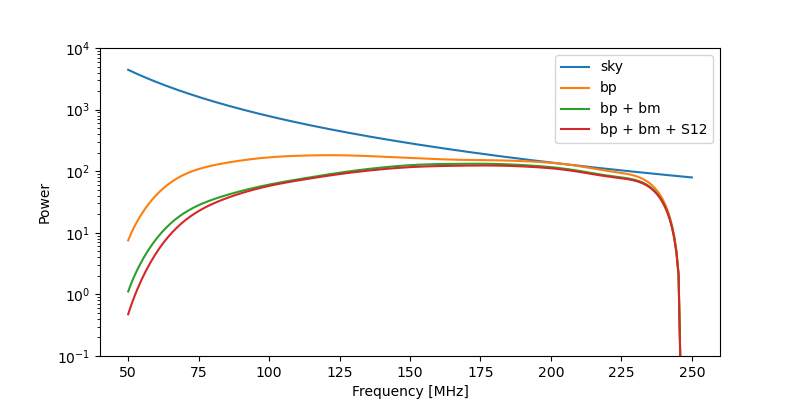

In [4]:
plt.figure(figsize=(8, 4))
Tsky = 180 * (freqs / 180e6) ** -2.5
S12  = 1 - S11
bp_norm = bandpass / bandpass.max()
zen_pix = healpy.vec2pix(simulator.beam._nside, 0, 0, 1)
bm_zen  = simulator.beam.map[zen_pix, :]          # beam response at zenith, (nfreq,)
plt.plot(freqs / 1e6, Tsky,                    label='sky')
plt.plot(freqs / 1e6, Tsky * bp_norm,          label='bp')
plt.plot(freqs / 1e6, Tsky * bp_norm * bm_zen, label='bp + bm')
plt.semilogy(freqs / 1e6, Tsky * bp_norm * bm_zen * S12, label='bp + bm + S12')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Power')
plt.ylim(1e-1, 1e4)
_ = plt.legend(loc='best')

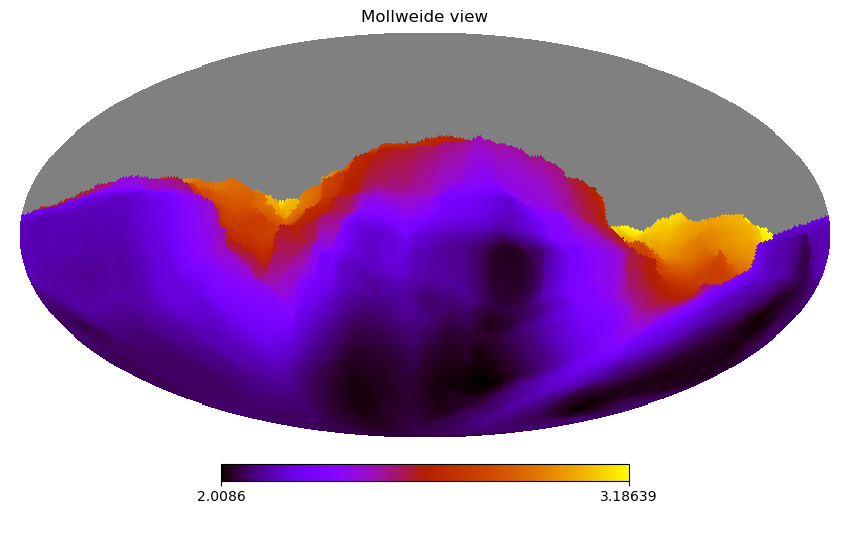

In [5]:
healpy.mollview(np.log10(simulator.terrain.map), cmap='gnuplot')

/home/aparsons/.local/share/mamba/envs/arp/lib/python3.11/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 7 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


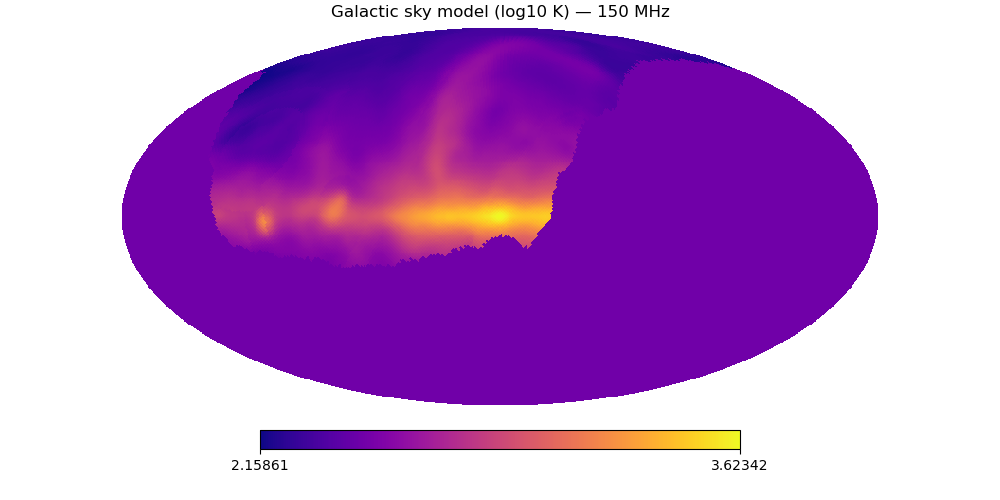

In [10]:
fig = plt.figure(figsize=(10, 5))
healpy.mollview(
    np.log10(simulator.sky_map(frame='gal', time=times[30], channels=CH0).clip(1)),
    fig=fig, cmap=cmap,
    title=f'Galactic sky model (log10 K) — {freqs[CH0]/1e6:.0f} MHz',
)

In [7]:
data = simulator.sim(times, azalts=azalts, S11=S11, bandpass=bandpass)
# data shape: (NTIMES, NAZ*NALT, NCHAN)

  1%|▎                                                   | 1/144 [02:13<5:18:55, 133.82s/it]


KeyboardInterrupt: 

In [ ]:
if False:
    np.savez(
        'sim_v004.npz',
        freqs   = freqs,
        data    = data,
        azalts  = azalts,
        times   = times.jd,
        lat     = LAT,
        lon     = LON,
        tx_crds_topo = terrain.tx_vecs_top,
        tx_flux      = terrain.tx_flux,
    )

In [ ]:
plt.figure()
plt.plot(simulator.freqs / 1e6, data[T0, :, :].T)
plt.xlabel('Frequency [MHz]')
_ = plt.ylabel('Temperature [K]')

# Notes on V001

 * 48 times spanning 1 day (w/ endpoints)
 * 18 Az and 18 Alt spanning 2$\pi$, no endpoints, rotating sky around $\hat x$ and $\hat z$ topocentric axes, respectively.
 * 201 frequency channels, linear beam/EoR/bandpass interpolation
 * 1 transmitter, flat spectrum, directly below antenna, transmitting every 16 ch
 * ground at uniform temperature, no reflections
 * T21cm model 120
 * GSM
 * random point sources
 * Vivaldi Beam
 * includes bandpass model, S11

# Notes on V002

 * 144 times spanning 1 day (w/ endpoints)
 * 36 Az and 36 Alt spanning 2$\pi$, no endpoints, rotating sky around $\hat x$ and $\hat z$ topocentric axes, respectively.
 * 1024 frequency channels, cubic beam/EoR/bandpass interpolation
 * 1 transmitter, flat spectrum, directly below antenna, transmitting every 16 ch
 * ground at uniform temperature, no reflections
 * T21cm model 120
 * GSM
 * random point sources
 * Vivaldi Beam
 * includes bandpass model, S11

# Notes on V003

 * Eigsep Bowtie v000 beam
 * S11 based on 75 $\Omega$ termination
 * all other parameters same as v002